In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mrdina","key":"b6c844a07a98994f50c2e8ef38a7311b"}'}

In [4]:
import os
import shutil
os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)

In [5]:
!pip install kaggle


In [6]:
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
intel-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip -o intel-image-classification.zip

In [8]:
import os

os.listdir("seg_train/seg_train")

['forest', 'street', 'sea', 'buildings', 'mountain', 'glacier']

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
img_size = (150, 150)
batch_size = 32



train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2

)


train_data = train_datagen.flow_from_directory(
    "seg_train/seg_train",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    "seg_train/seg_train",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.


In [11]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))


model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))


model.add(Dense(6, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


351/351 ━━━━━━━━━━━━━━━━━━━━ 421s 1s/step - accuracy: 0.5389 - loss: 1.1803 - val_accuracy: 0.7347 - val_loss: 0.7169
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 428s 1s/step - accuracy: 0.7708 - loss: 0.6256 - val_accuracy: 0.7942 - val_loss: 0.5971
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 401s 1s/step - accuracy: 0.8318 - loss: 0.4678 - val_accuracy: 0.8131 - val_loss: 0.5461
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 402s 1s/step - accuracy: 0.8753 - loss: 0.3403 - val_accuracy: 0.8081 - val_loss: 0.5721
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 401s 1s/step - accuracy: 0.9261 - loss: 0.2162 - val_accuracy: 0.8245 - val_loss: 0.6157
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 394s 1s/step - accuracy: 0.9562 - loss: 0.1301 - val_accuracy: 0.7967 - val_loss: 0.7916
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 410s 1s/step - accuracy: 0.9718 - loss: 0.0863 - val_accuracy: 0.8067 - val_loss: 0.8483
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 389s 1s/step - accuracy: 0.9814 - loss: 0.0658 - val_accuracy: 0.773

In [15]:
history

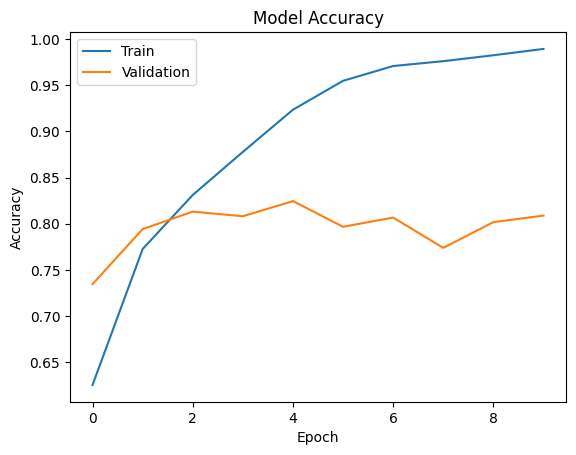

In [16]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

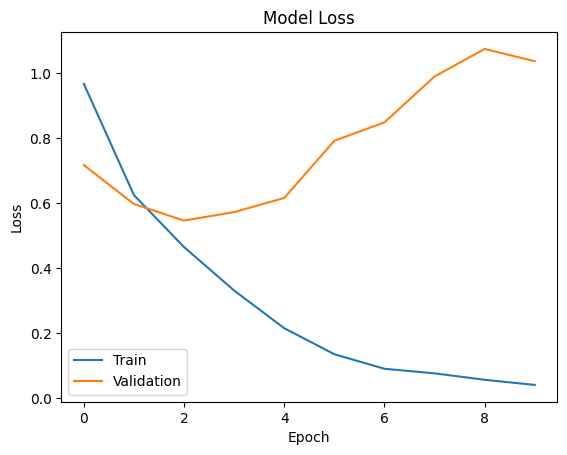

In [17]:

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [18]:
from sklearn.metrics import confusion_matrix
import numpy as np

In [19]:
predictions = model.predict(val_data)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_data.classes

88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 285ms/step


In [20]:
cm = confusion_matrix(true_classes, predicted_classes)
print(cm)

[[73 83 86 71 70 55]
 [67 67 74 79 84 83]
 [82 83 81 95 69 70]
 [89 90 78 84 93 68]
 [69 72 73 90 88 62]
 [90 96 74 77 72 67]]


In [21]:
from sklearn.metrics import classification_report

class_labels = list(val_data.class_indices.keys())

print(classification_report(true_classes, predicted_classes, target_names=class_labels))

              precision    recall  f1-score   support

   buildings       0.16      0.17      0.16       438
      forest       0.14      0.15      0.14       454
     glacier       0.17      0.17      0.17       480
    mountain       0.17      0.17      0.17       502
         sea       0.18      0.19      0.19       454
      street       0.17      0.14      0.15       476

    accuracy                           0.16      2804
   macro avg       0.16      0.16      0.16      2804
weighted avg       0.16      0.16      0.16      2804



In [22]:
from tensorflow.keras.layers import BatchNormalization, Dropout

model = Sequential()


model.add(Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))


model.add(Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))


model.add(Flatten())

model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(6,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 660s 2s/step - accuracy: 0.4793 - loss: 4.5198 - val_accuracy: 0.4223 - val_loss: 3.2813
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 708s 2s/step - accuracy: 0.6120 - loss: 1.1176 - val_accuracy: 0.7168 - val_loss: 0.9087
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 670s 2s/step - accuracy: 0.6501 - loss: 0.9244 - val_accuracy: 0.3848 - val_loss: 3.2180
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 665s 2s/step - accuracy: 0.6969 - loss: 0.8480 - val_accuracy: 0.6805 - val_loss: 1.2821
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 631s 2s/step - accuracy: 0.7306 - loss: 0.7646 - val_accuracy: 0.6947 - val_loss: 1.2339
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 666s 2s/step - accuracy: 0.7703 - loss: 0.6693 - val_accuracy: 0.7857 - val_loss: 0.6889
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 614s 2s/step - accuracy: 0.7960 - loss: 0.5902 - val_accuracy: 0.6683 - val_loss: 0.9862
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 617s 2s/step - accuracy: 0.8008 - loss: 0.5661 - val_accu

In [25]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [26]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

/tmp/ipykernel_19661/632844194.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [27]:
for layer in base_model.layers:
    layer.trainable = False

In [28]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(6, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [29]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 191s 532ms/step - accuracy: 0.7609 - loss: 0.6553 - val_accuracy: 0.8905 - val_loss: 0.2936
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 187s 533ms/step - accuracy: 0.8781 - loss: 0.3297 - val_accuracy: 0.8927 - val_loss: 0.2904
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 174s 495ms/step - accuracy: 0.8931 - loss: 0.2902 - val_accuracy: 0.9012 - val_loss: 0.2714
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 176s 502ms/step - accuracy: 0.9069 - loss: 0.2535 - val_accuracy: 0.9019 - val_loss: 0.2761
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 202s 503ms/step - accuracy: 0.9123 - loss: 0.2357 - val_accuracy: 0.9037 - val_loss: 0.2817
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 181s 515ms/step - accuracy: 0.9142 - loss: 0.2289 - val_accuracy: 0.8955 - val_loss: 0.2754
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 170s 485ms/step - accuracy: 0.9183 - loss: 0.2198 - val_accuracy: 0.9058 - val_loss: 0.2630
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 171s 487ms/step - accuracy: 0.9187 -

In [31]:
model.save("intel_scene_classifier.h5")

In [32]:
from google.colab import files
files.download('intel_scene_classifier.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
from tensorflow.keras.models import load_model

model = load_model("intel_scene_classifier.h5")

In [34]:
from google.colab import files
uploaded = files.upload()

Saving download.jpg to download.jpg


In [35]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "download.jpg"

img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img)

img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [36]:
prediction = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 964ms/step


In [37]:
class_names = ['buildings','forest','glacier','mountain','sea','street']

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Class:", predicted_class)


Predicted Class: forest
